# SpatioEv Manuscript — Supplementary Figure Generation

Generates all supplementary figures from pre-cached data. No heavy recomputation needed.

**Outputs:** `manuscript/figures/supplementary/` (PDF + PNG at 300 dpi)

| Sup Fig | Content | Data |
|---------|---------|------|
| S1 | Per-sample pseudotime: exp_3, exp_4, exp_5 | spatial_cells pkl + pooled results |
| S2 | Feature selection & block PCA | pseudotime_feature_*.csv |
| S3 | Epithelial-intrinsic vs contextual trajectory | epithelial_intrinsic_pseudotime_result_df.pkl |
| S4 | SpatialCellChat / microenvironment interactions | trajectory_microenvironment_interactions/ |
| S5 | Per-sample pseudotime concordance | pooled_vs_persample_pseudotime_concordance.csv |
| S6 | Xenium BANKSY + LR interactions | xenium_banksy_pseudotime/ + xenium_lr figures |
| S7–S11 | Package demo: QC, phenotyping, density, spatial stats, ECM | existing result figures |

In [1]:
from pathlib import Path
import warnings, shutil
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.image as mpimg
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

mpl.rcParams.update({
    'font.family': 'Arial', 'font.size': 7,
    'axes.labelsize': 7, 'axes.titlesize': 8,
    'xtick.labelsize': 6, 'ytick.labelsize': 6,
    'legend.fontsize': 6, 'axes.linewidth': 0.6,
    'xtick.major.width': 0.6, 'ytick.major.width': 0.6,
    'xtick.major.size': 2.5, 'ytick.major.size': 2.5,
    'lines.linewidth': 1.0, 'figure.dpi': 150,
    'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'pdf.fonttype': 42, 'ps.fonttype': 42,
})

BASE       = Path('/Users/shihongwu/SpatioEv')
RES_EXP2   = BASE / 'paper/notebooks/results/pseudotime_exp2'
COMB_DIR   = BASE / 'data/combined_exp_2_3_4_5'
XENIUM_FIG = BASE / 'data/xenium_pancreas_10x/figures'
TRAJ_FIG   = BASE / 'paper/notebooks/results/trajectory_microenvironment_interactions/figures'
BANKSY_FIG = BASE / 'paper/notebooks/results/xenium_banksy_pseudotime'
ECM_FIG    = BASE / 'paper/notebooks/results/ra_oa_ecm_cell/spatioev_module_paper_applications/figures'
CHP_FIG    = BASE / 'paper/notebooks/results/ra_oa_ecm_cell/chp_density_micro_holes_col6_dark_segmentation/figures'
LINK_FIG   = BASE / 'paper/notebooks/results/ra_oa_ecm_cell/figures/00_prepare_links'
OUT        = BASE / 'manuscript/figures/supplementary'
OUT.mkdir(parents=True, exist_ok=True)

def save_fig(fig, name):
    for ext in ('pdf', 'png'):
        fig.savefig(OUT / f'{name}.{ext}', dpi=300, bbox_inches='tight')
    print(f'Saved: {name}')

def copy_fig(src, dest_name):
    src = Path(src)
    if src.exists():
        shutil.copy(src, OUT / dest_name)
        print(f'Copied: {dest_name}')
    else:
        print(f'MISSING: {src}')

def lowess_smooth(x, y, frac=0.25):
    xy = np.column_stack([x, y])
    xy = xy[~np.isnan(xy).any(axis=1)]
    xy = xy[np.argsort(xy[:, 0])]
    s = sm.nonparametric.lowess(xy[:, 1], xy[:, 0], frac=frac)
    return s[:, 0], s[:, 1]

SAMPLE_LABELS = {
    '40331_1': 'Normal pancreas', '33694_1': 'PDAC (Grade I–II)',
    '35559_1': 'PDAC (Stage III)', '34434_1': 'PDAC (Grade 3)',
}
SAMPLE_PALETTE = {
    '40331_1': '#4393C3', '33694_1': '#92C5DE',
    '35559_1': '#F4A582', '34434_1': '#B2182B',
}
MODULE_LABELS = {
    'pdac_early_duct_anchor_score':      'Early-duct anchor',
    'pdac_panin_like_dysplasia_score':   'PanIN-like dysplasia',
    'pdac_invasive_gland_forming_score': 'Invasive gland-forming',
    'pdac_invasion_desmoplasia_score':   'Invasion–desmoplasia',
    'pdac_proliferation_score':          'Proliferation',
}
MODULE_COLS = list(MODULE_LABELS.keys())
PANIN_COLS = [
    'panin_validation__normal_duct_like_score',
    'panin_validation__lg_panin_like_score',
    'panin_validation__hg_panin_like_score',
    'panin_validation__invasive_desmoplastic_context_score',
]
PANIN_LABELS = [
    'Normal duct-like', 'Low-grade PanIN', 'High-grade PanIN', 'Invasive–desmoplastic'
]
PANIN_COLORS = ['#2166AC', '#92C5DE', '#F4A582', '#B2182B']

print('Setup complete. Output:', OUT)

Setup complete. Output: /Users/shihongwu/SpatioEv/manuscript/figures/supplementary


---
## Supplementary Figure 1 — Per-sample pseudotime: exp_3, exp_4, exp_5 (normal)

Saved: supfig1_33694_1_pseudotime


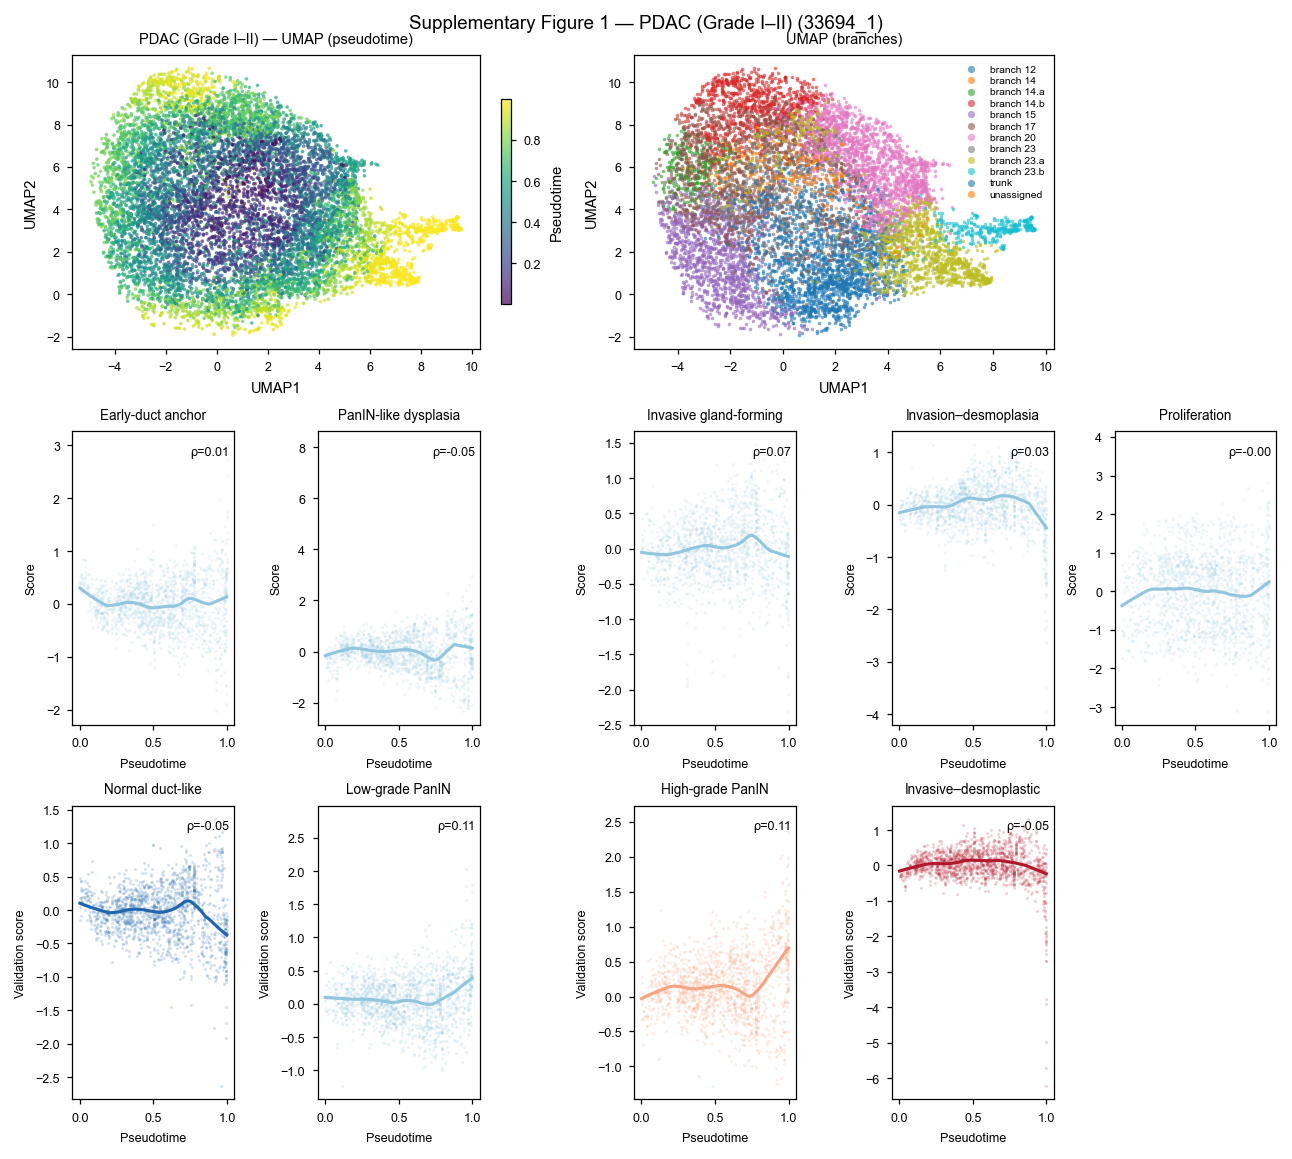

Saved: supfig1_35559_1_pseudotime


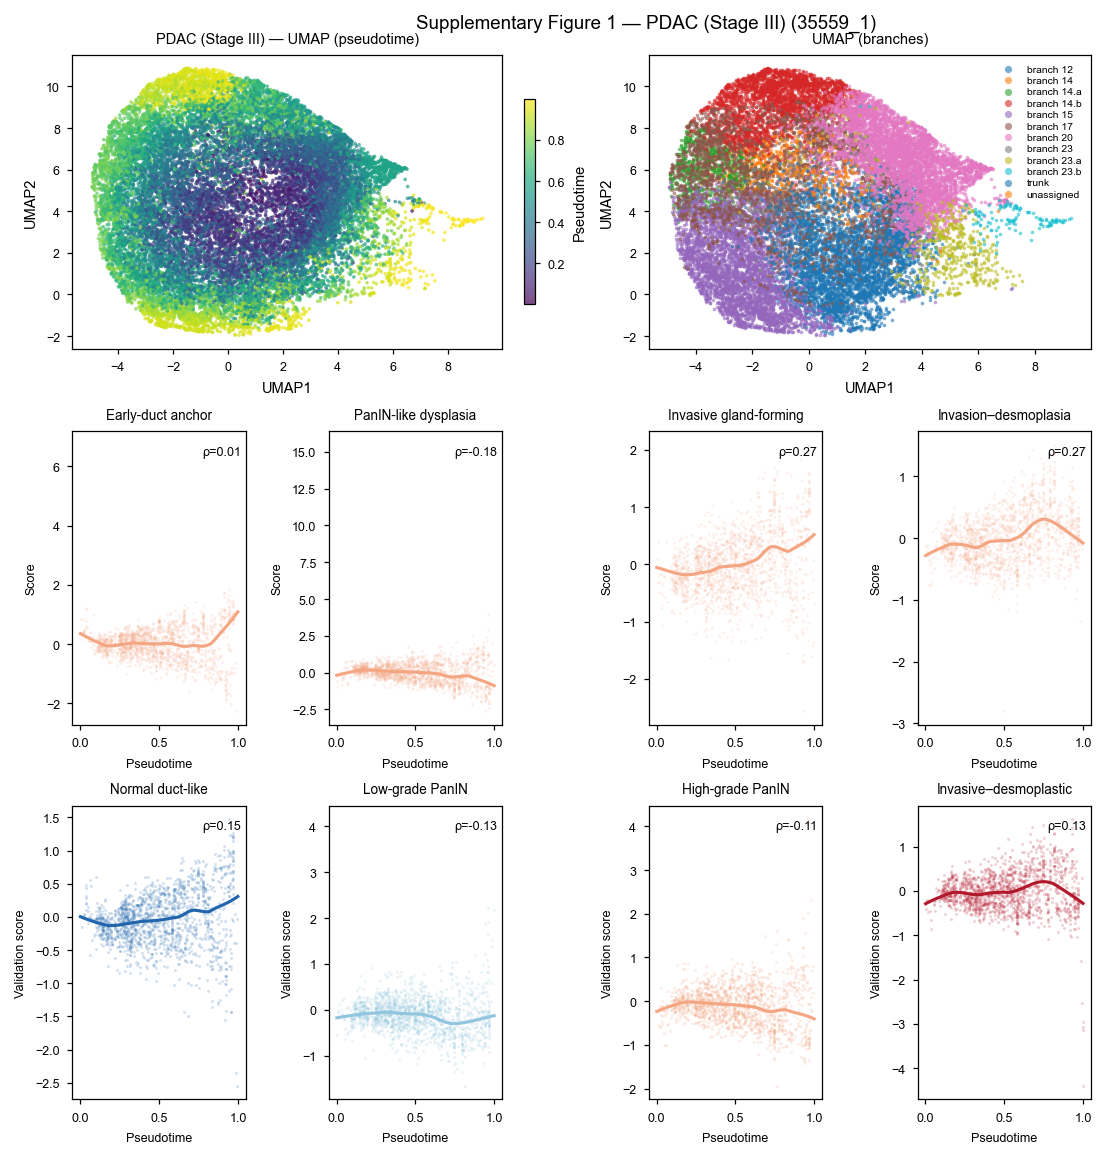

Saved: supfig1_40331_1_pseudotime


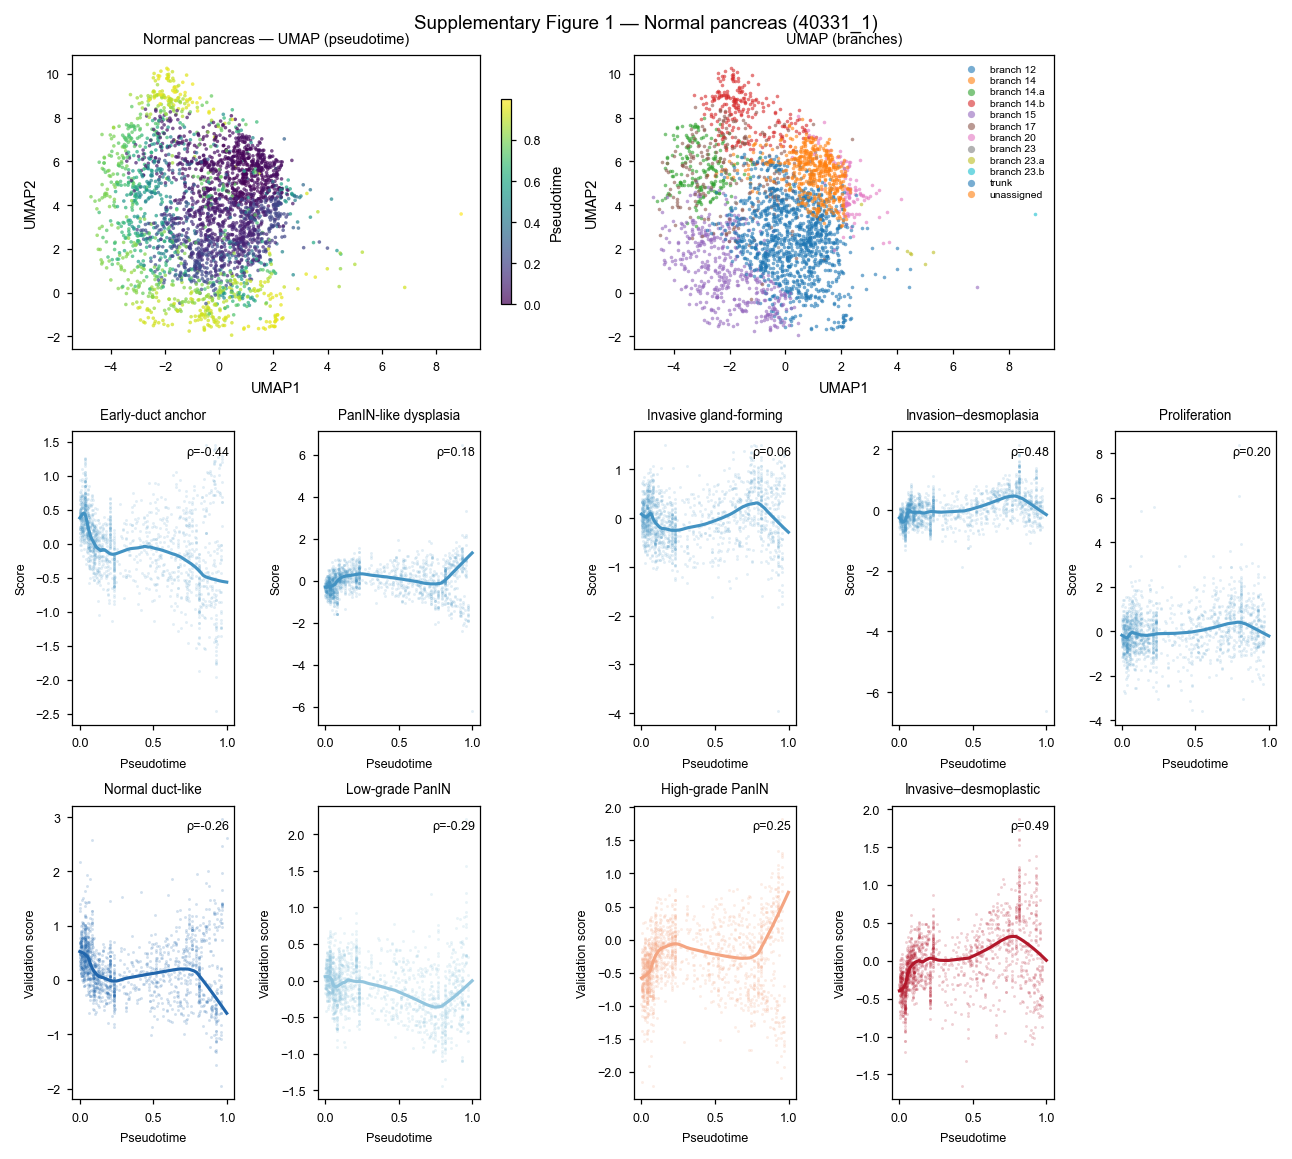

In [2]:
# Load pooled data once
df_pooled   = pd.read_pickle(COMB_DIR / 'pooled_niche_result_df.pkl')
df_panin_all = pd.read_pickle(COMB_DIR / 'pooled_pathology_with_panin_validation_scores.pkl')

SPATIAL_VERSION = 'auto_branch_n36_v5_contextual'
SUP1_SAMPLES = ['33694_1', '35559_1', '40331_1']   # exp_3, exp_4, exp_5

for sample_id in SUP1_SAMPLES:
    label = SAMPLE_LABELS.get(sample_id, sample_id)
    color = SAMPLE_PALETTE.get(sample_id, '#555555')

    # ── per-sample niche table ─────────────────────────────────────────────
    df_s = df_pooled[df_pooled['sample_id'] == sample_id].copy()
    df_pan_s = df_panin_all[df_panin_all['sample_id'] == sample_id].copy()
    # merge panin validation into niche table
    merge_cols = ['pancreatic ductal epithelium_mask_component', 'image_id']
    if 'image_id' in df_pan_s.columns:
        df_s = df_s.merge(
            df_pan_s[merge_cols + [c for c in PANIN_COLS if c in df_pan_s.columns]],
            on=merge_cols, how='left'
        )

    pt_col = 'pooled_pseudotime_q'
    mod_cols = [c for c in MODULE_COLS if c in df_s.columns]
    panin_cols = [c for c in PANIN_COLS if c in df_s.columns]

    # ── Figure layout: 3 rows × N cols ────────────────────────────────────
    n_mod = len(mod_cols)
    n_pan = len(panin_cols)
    fig = plt.figure(figsize=(max(n_mod, n_pan) * 1.7, 7.5), constrained_layout=True)
    gs = gridspec.GridSpec(3, max(n_mod, n_pan, 2), figure=fig)

    # Row 0: UMAP coloured by pseudotime + branch
    ax_umap_pt = fig.add_subplot(gs[0, :2])
    sc = ax_umap_pt.scatter(df_s['UMAP1'], df_s['UMAP2'],
                            c=df_s[pt_col], cmap='viridis', s=3,
                            linewidths=0, alpha=0.7, rasterized=True)
    plt.colorbar(sc, ax=ax_umap_pt, shrink=0.7, label='Pseudotime')
    ax_umap_pt.set_title(f'{label} — UMAP (pseudotime)', fontsize=7)
    ax_umap_pt.set_xlabel('UMAP1'); ax_umap_pt.set_ylabel('UMAP2')

    if n_mod > 2:
        ax_umap_br = fig.add_subplot(gs[0, 2:4])
        branches = sorted(df_s['major_branch'].dropna().unique())
        pal = dict(zip(branches, sns.color_palette('tab10', len(branches))))
        for br, grp in df_s.groupby('major_branch'):
            ax_umap_br.scatter(grp['UMAP1'], grp['UMAP2'], c=[pal.get(br, '#ccc')],
                               s=3, linewidths=0, alpha=0.6, rasterized=True, label=br)
        ax_umap_br.legend(markerscale=2, frameon=False, fontsize=5, labelspacing=0.2)
        ax_umap_br.set_title('UMAP (branches)', fontsize=7)
        ax_umap_br.set_xlabel('UMAP1'); ax_umap_br.set_ylabel('UMAP2')

    # Row 1: Module LOWESS trends
    for ci, col in enumerate(mod_cols[:max(n_mod, 5)]):
        ax = fig.add_subplot(gs[1, ci])
        v = pd.to_numeric(df_s[col], errors='coerce')
        pt = pd.to_numeric(df_s[pt_col], errors='coerce')
        mask = ~(np.isnan(v) | np.isnan(pt))
        if mask.sum() < 20:
            ax.set_visible(False); continue
        idx = np.random.choice(np.where(mask)[0], size=min(1500, mask.sum()), replace=False)
        ax.scatter(pt.values[idx], v.values[idx], c=color, s=2, alpha=0.15,
                   linewidths=0, rasterized=True)
        try:
            lx, ly = lowess_smooth(pt.values[mask], v.values[mask])
            ax.plot(lx, ly, color=color, linewidth=1.5)
        except Exception:
            pass
        r, _ = stats.spearmanr(pt.values[mask], v.values[mask])
        ax.text(0.97, 0.95, f'ρ={r:.2f}', transform=ax.transAxes,
                ha='right', va='top', fontsize=6)
        ax.set_title(MODULE_LABELS.get(col, col), fontsize=6.5)
        ax.set_xlabel('Pseudotime', fontsize=6)
        ax.set_ylabel('Score', fontsize=6)
        ax.set_xlim(-0.05, 1.05)

    # Row 2: PanIN validation trends
    for ci, (col, plabel, pc) in enumerate(zip(panin_cols, PANIN_LABELS, PANIN_COLORS)):
        ax = fig.add_subplot(gs[2, ci])
        v = pd.to_numeric(df_s[col], errors='coerce')
        pt = pd.to_numeric(df_s[pt_col], errors='coerce')
        mask = ~(np.isnan(v) | np.isnan(pt))
        if mask.sum() < 20:
            ax.set_visible(False); continue
        idx = np.random.choice(np.where(mask)[0], size=min(1500, mask.sum()), replace=False)
        ax.scatter(pt.values[idx], v.values[idx], c=pc, s=2, alpha=0.2,
                   linewidths=0, rasterized=True)
        try:
            lx, ly = lowess_smooth(pt.values[mask], v.values[mask], frac=0.3)
            ax.plot(lx, ly, color=pc, linewidth=1.5)
        except Exception:
            pass
        r, _ = stats.spearmanr(pt.values[mask], v.values[mask])
        ax.text(0.97, 0.95, f'ρ={r:.2f}', transform=ax.transAxes,
                ha='right', va='top', fontsize=6)
        ax.set_title(plabel, fontsize=6.5)
        ax.set_xlabel('Pseudotime', fontsize=6)
        ax.set_ylabel('Validation score', fontsize=6)
        ax.set_xlim(-0.05, 1.05)

    fig.suptitle(f'Supplementary Figure 1 — {label} ({sample_id})', fontsize=9, y=1.01)
    save_fig(fig, f'supfig1_{sample_id}_pseudotime')
    plt.show()

---
## Supplementary Figure 2 — Feature selection and within-block PCA

Saved: supfig2_feature_selection_pca


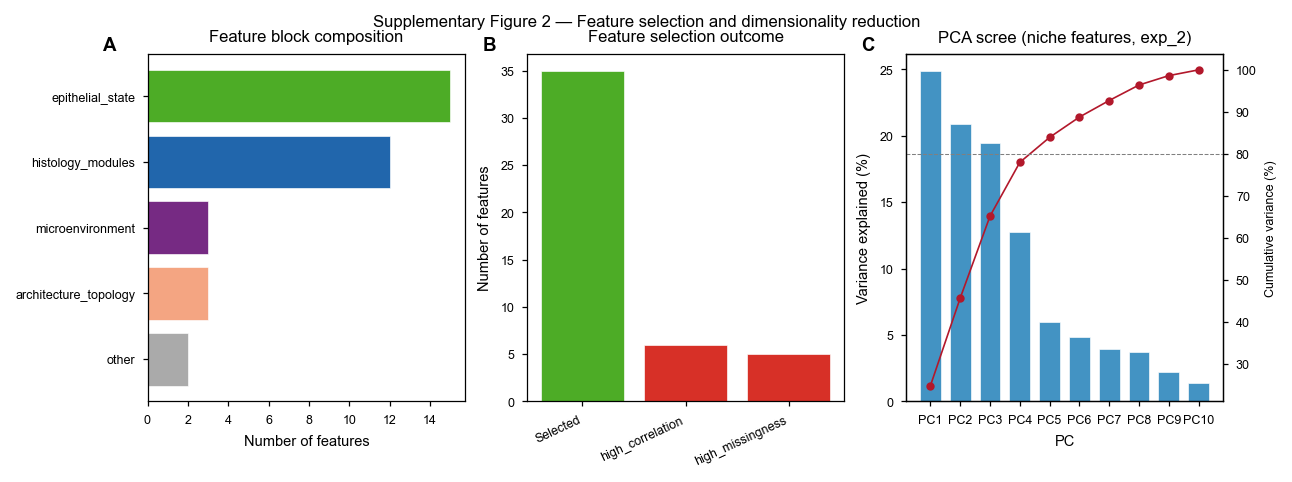

In [3]:
df_blocks = pd.read_csv(RES_EXP2 / 'pseudotime_feature_blocks.csv')
df_diag   = pd.read_csv(RES_EXP2 / 'pseudotime_feature_diagnostics.csv')
df_pca_ev = pd.read_csv(RES_EXP2 / 'pca_explained_variance.csv')

fig, axes = plt.subplots(1, 3, figsize=(8.5, 3.0), constrained_layout=True)

# Panel A: Feature block composition bar chart
ax = axes[0]
block_counts = df_blocks['feature_block'].value_counts().sort_values()
BLOCK_COLORS = {
    'histology_modules':      '#2166AC',
    'epithelial_state':       '#4DAC26',
    'architecture_topology':  '#F4A582',
    'microenvironment':       '#762A83',
    'other':                  '#AAAAAA',
}
colors = [BLOCK_COLORS.get(b, '#888888') for b in block_counts.index]
ax.barh(block_counts.index, block_counts.values, color=colors, edgecolor='white', linewidth=0.3)
ax.set_xlabel('Number of features')
ax.set_title('Feature block composition')
ax.text(-0.14, 1.05, 'A', transform=ax.transAxes, fontsize=9, fontweight='bold', va='top')

# Panel B: Feature selection summary (selected vs dropped, by reason)
ax = axes[1]
drop_counts = df_diag[df_diag['selected'] == False]['drop_reason'].value_counts()
n_selected  = df_diag['selected'].sum()
summary = pd.concat([pd.Series({'Selected': n_selected}), drop_counts])
bar_colors = ['#4DAC26'] + ['#D73027'] * len(drop_counts)
ax.bar(summary.index, summary.values, color=bar_colors, edgecolor='white', linewidth=0.3)
ax.set_xticklabels(summary.index, rotation=25, ha='right', fontsize=6)
ax.set_ylabel('Number of features')
ax.set_title('Feature selection outcome')
ax.text(-0.14, 1.05, 'B', transform=ax.transAxes, fontsize=9, fontweight='bold', va='top')

# Panel C: Variance explained (same scree from main Fig 1D, shown here for reference)
ax = axes[2]
n_show = min(10, len(df_pca_ev))
ax.bar(df_pca_ev['PC'][:n_show],
       df_pca_ev['explained_variance_ratio'][:n_show] * 100,
       color='#4393C3', edgecolor='white', linewidth=0.3, width=0.7)
ax2c = ax.twinx()
ax2c.plot(df_pca_ev['PC'][:n_show],
          df_pca_ev['cumulative_variance_ratio'][:n_show] * 100,
          'o-', color='#B2182B', markersize=3, linewidth=0.8)
ax2c.axhline(80, color='gray', linestyle='--', linewidth=0.5)
ax2c.set_ylabel('Cumulative variance (%)', fontsize=6)
ax.set_xlabel('PC'); ax.set_ylabel('Variance explained (%)')
ax.set_title('PCA scree (niche features, exp_2)')
ax.text(-0.14, 1.05, 'C', transform=ax.transAxes, fontsize=9, fontweight='bold', va='top')

fig.suptitle('Supplementary Figure 2 — Feature selection and dimensionality reduction', fontsize=8, y=1.02)
save_fig(fig, 'supfig2_feature_selection_pca')
plt.show()

---
## Supplementary Figure 3 — Epithelial-intrinsic vs contextual trajectory

Saved: supfig3_epi_vs_contextual_pseudotime


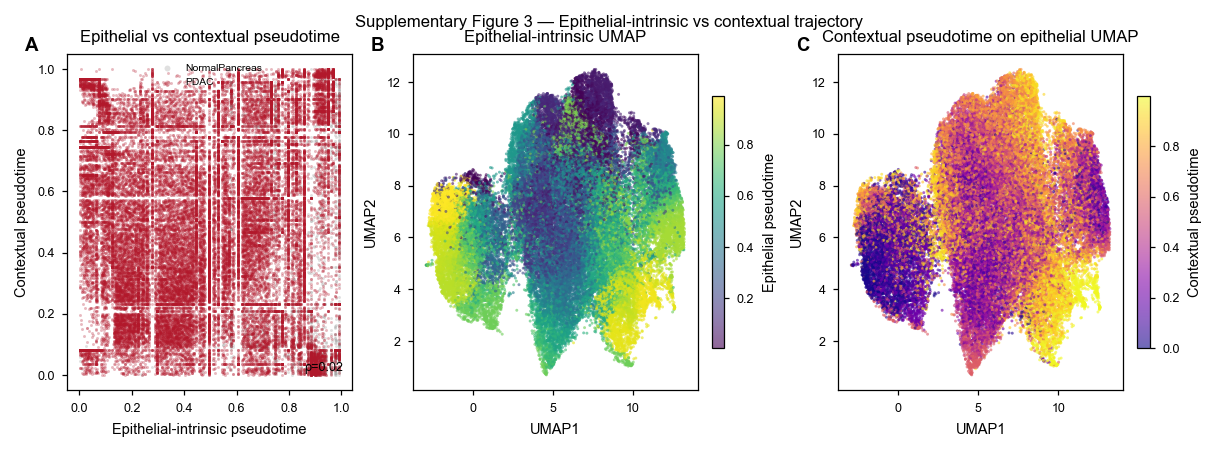

Copied: supfig3_epi_vs_contextual_pseudotime_pregenerated.pdf


In [4]:
df_epi = pd.read_pickle(COMB_DIR / 'epithelial_intrinsic_pseudotime_result_df.pkl')
df_pooled_full = pd.read_pickle(COMB_DIR / 'pooled_niche_result_df.pkl')
df_pan_all = pd.read_pickle(COMB_DIR / 'pooled_pathology_with_panin_validation_scores.pkl')

# Merge epithelial + contextual pseudotime
df_both = df_epi[['pancreatic ductal epithelium_mask_component', 'image_id',
                   'epithelial_pseudotime_q', 'contextual_pseudotime_q',
                   'epithelial_UMAP1', 'epithelial_UMAP2',
                   'sample_id', 'disease_group']].merge(
    df_pooled_full[['pancreatic ductal epithelium_mask_component', 'image_id',
                    'pooled_pseudotime_q', 'major_branch']],
    on=['pancreatic ductal epithelium_mask_component', 'image_id'], how='inner'
)

fig, axes = plt.subplots(1, 3, figsize=(8.0, 2.8), constrained_layout=True)

# Panel A: Scatter of epithelial vs contextual pseudotime
ax = axes[0]
disease_pal = {'Normal': '#4393C3', 'PDAC': '#B2182B'}
for dg, grp in df_both.groupby('disease_group'):
    ax.scatter(grp['epithelial_pseudotime_q'], grp['contextual_pseudotime_q'],
               c=disease_pal.get(dg, '#999'), s=2, alpha=0.3, linewidths=0,
               rasterized=True, label=dg)
r, p = stats.spearmanr(
    df_both['epithelial_pseudotime_q'].dropna(),
    df_both['contextual_pseudotime_q'].dropna()
)
ax.text(0.97, 0.05, f'ρ={r:.2f}', transform=ax.transAxes,
        ha='right', va='bottom', fontsize=6)
ax.set_xlabel('Epithelial-intrinsic pseudotime')
ax.set_ylabel('Contextual pseudotime')
ax.set_title('Epithelial vs contextual pseudotime')
ax.legend(markerscale=2, frameon=False, fontsize=5)
ax.text(-0.15, 1.05, 'A', transform=ax.transAxes, fontsize=9, fontweight='bold', va='top')

# Panel B: UMAP coloured by epithelial pseudotime
ax = axes[1]
sc = ax.scatter(df_both['epithelial_UMAP1'], df_both['epithelial_UMAP2'],
                c=df_both['epithelial_pseudotime_q'], cmap='viridis',
                s=2, linewidths=0, alpha=0.6, rasterized=True)
plt.colorbar(sc, ax=ax, shrink=0.75, label='Epithelial pseudotime')
ax.set_xlabel('UMAP1'); ax.set_ylabel('UMAP2')
ax.set_title('Epithelial-intrinsic UMAP')
ax.text(-0.15, 1.05, 'B', transform=ax.transAxes, fontsize=9, fontweight='bold', va='top')

# Panel C: UMAP coloured by contextual pseudotime
ax = axes[2]
sc = ax.scatter(df_both['epithelial_UMAP1'], df_both['epithelial_UMAP2'],
                c=df_both['contextual_pseudotime_q'], cmap='plasma',
                s=2, linewidths=0, alpha=0.6, rasterized=True)
plt.colorbar(sc, ax=ax, shrink=0.75, label='Contextual pseudotime')
ax.set_xlabel('UMAP1'); ax.set_ylabel('UMAP2')
ax.set_title('Contextual pseudotime on epithelial UMAP')
ax.text(-0.15, 1.05, 'C', transform=ax.transAxes, fontsize=9, fontweight='bold', va='top')

fig.suptitle('Supplementary Figure 3 — Epithelial-intrinsic vs contextual trajectory', fontsize=8, y=1.02)
save_fig(fig, 'supfig3_epi_vs_contextual_pseudotime')
plt.show()

# Also copy the pre-generated composite version
copy_fig(COMB_DIR / 'fig_epi_vs_contextual_pseudotime.pdf',
         'supfig3_epi_vs_contextual_pseudotime_pregenerated.pdf')

---
## Supplementary Figure 4 — Microenvironment and interaction dynamics (multiplexed IMC)

Copied: supfig4A_microenv_trends.png
Copied: supfig4B_microenv_branch_heatmap.png
Copied: supfig4C_colocalisation_trends.png
Copied: supfig4D_branch_state_heatmap.png
Copied: supfig4E_transition_events.png
Copied: supfig4F_subway_map.png
Saved: supfig4_microenv_dynamics_composite


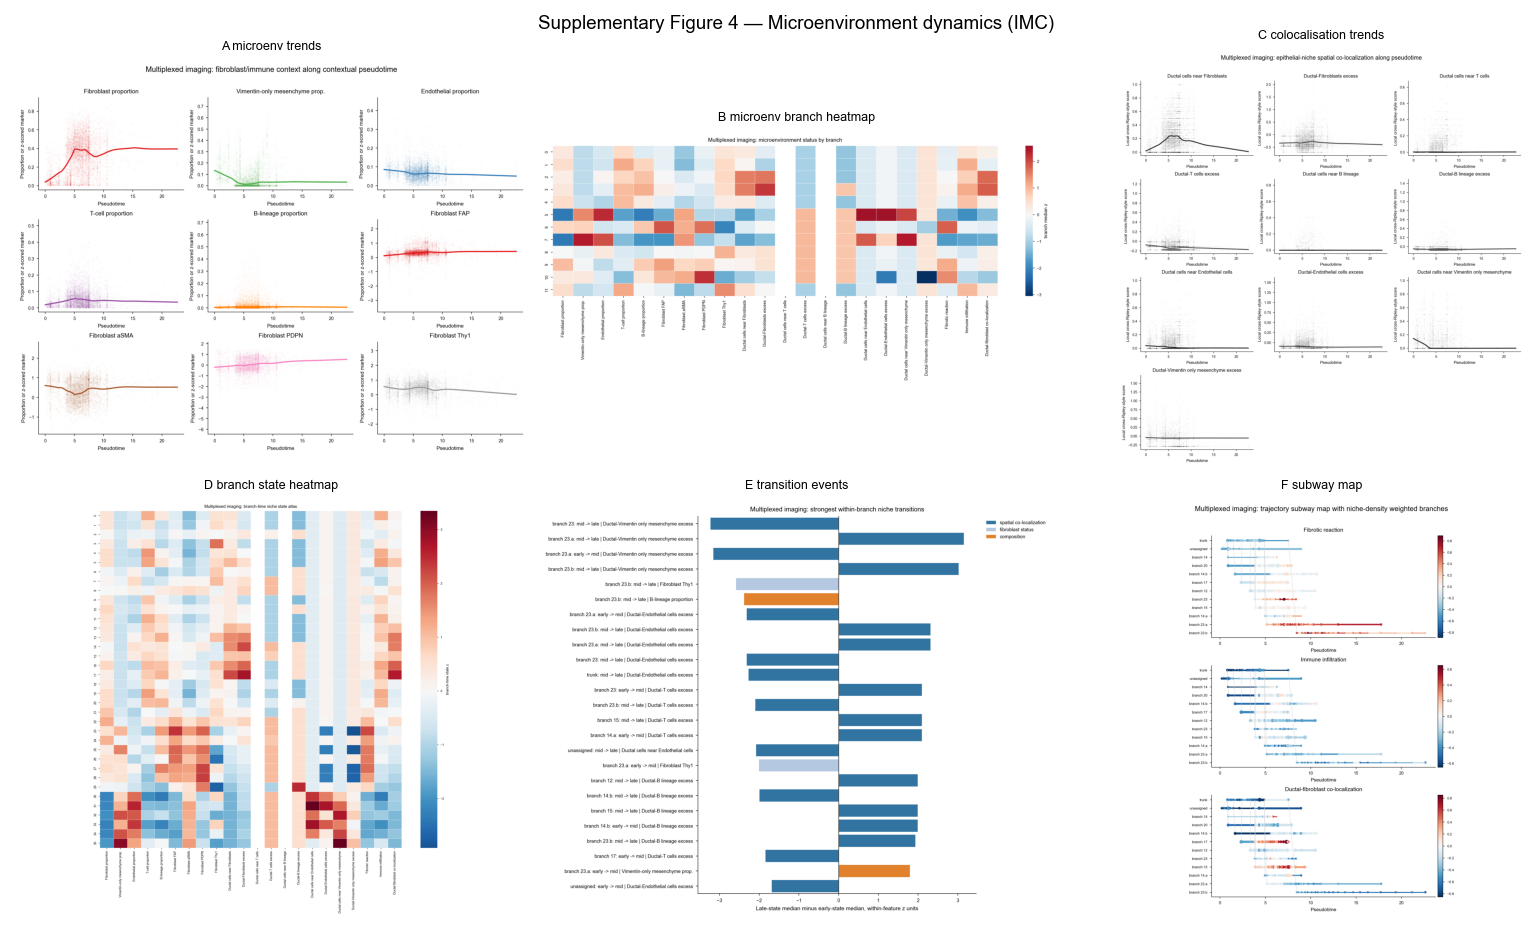

In [5]:
# Copy pre-generated figures from trajectory_microenvironment_interactions
traj_panels = {
    'supfig4A_microenv_trends.png':          'multiplexed_microenvironment_trends_contextual.png',
    'supfig4B_microenv_branch_heatmap.png':  'multiplexed_microenvironment_branch_heatmap.png',
    'supfig4C_colocalisation_trends.png':    'multiplexed_epithelial_niche_colocalization_trends.png',
    'supfig4D_branch_state_heatmap.png':     'multiplexed_branch_time_state_heatmap.png',
    'supfig4E_transition_events.png':        'multiplexed_branch_time_transition_events.png',
    'supfig4F_subway_map.png':               'multiplexed_trajectory_subway_map_key_programs.png',
}
for dest, src in traj_panels.items():
    copy_fig(TRAJ_FIG / src, dest)

# Composite: show panels in a grid for reference
panel_files = [OUT / d for d in traj_panels.keys() if (OUT / d).exists()]
n = len(panel_files)
ncols = 3; nrows = (n + 2) // 3
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 3.0), constrained_layout=True)
axes = np.array(axes).reshape(-1)
for ax, pf in zip(axes, panel_files):
    ax.imshow(mpimg.imread(pf))
    ax.set_title(pf.stem.replace('supfig4', '').replace('_', ' ').strip(), fontsize=6)
    ax.axis('off')
for ax in axes[n:]:
    ax.set_visible(False)
fig.suptitle('Supplementary Figure 4 — Microenvironment dynamics (IMC)', fontsize=9, y=1.01)
save_fig(fig, 'supfig4_microenv_dynamics_composite')
plt.show()

---
## Supplementary Figure 5 — Per-sample pseudotime concordance

Saved: supfig5_pseudotime_concordance


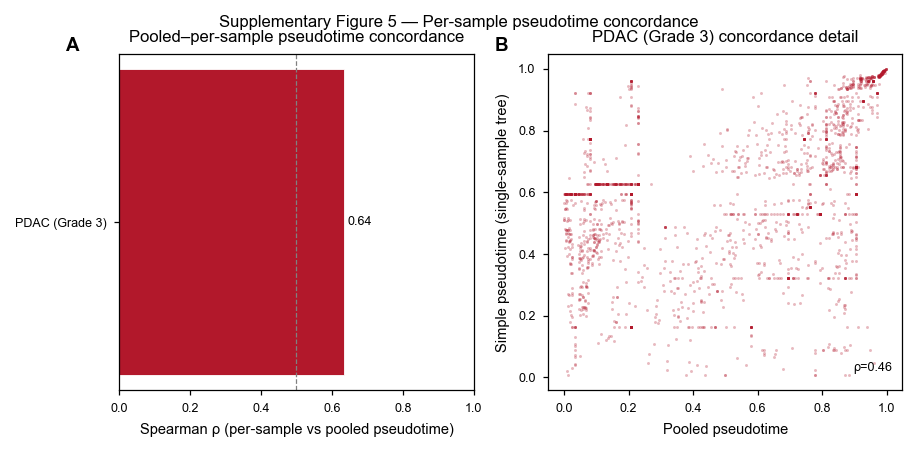

In [6]:
df_conc = pd.read_csv(COMB_DIR / 'pooled_vs_persample_pseudotime_concordance.csv')

fig, axes = plt.subplots(1, 2, figsize=(6.0, 2.8), constrained_layout=True)

# Panel A: Bar chart of Spearman ρ per sample
ax = axes[0]
colors = [SAMPLE_PALETTE.get(s, '#888') for s in df_conc['sample_id']]
labels = [SAMPLE_LABELS.get(s, s) for s in df_conc['sample_id']]
bars = ax.barh(labels, df_conc['spearman_rho_q'],
               color=colors, edgecolor='white', linewidth=0.4)
ax.axvline(0.5, color='gray', linestyle='--', linewidth=0.6)
ax.set_xlabel('Spearman ρ (per-sample vs pooled pseudotime)')
ax.set_title('Pooled–per-sample pseudotime concordance')
ax.set_xlim(0, 1)
for bar, val in zip(bars, df_conc['spearman_rho_q']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=6)
ax.text(-0.15, 1.05, 'A', transform=ax.transAxes, fontsize=9, fontweight='bold', va='top')

# Panel B: Concordance detail for exp_2 (most PDAC-enriched)
# Scatter of per-sample vs pooled pseudotime for 34434_1
ax = axes[1]
sample_id = '34434_1'
df_s = df_pooled[df_pooled['sample_id'] == sample_id]
# per-sample pseudotime is simple_pseudotime_q (fitted to pooled tree but without other samples)
# use pooled_pseudotime_q as X, simple_pseudotime_q as Y
if 'simple_pseudotime_q' in df_s.columns:
    x = pd.to_numeric(df_s['pooled_pseudotime_q'], errors='coerce')
    y = pd.to_numeric(df_s['simple_pseudotime_q'], errors='coerce')
    mask = ~(np.isnan(x) | np.isnan(y))
    idx = np.random.choice(np.where(mask)[0], size=min(2000, mask.sum()), replace=False)
    ax.scatter(x.values[idx], y.values[idx], c=SAMPLE_PALETTE[sample_id],
               s=2, alpha=0.3, linewidths=0, rasterized=True)
    r, _ = stats.spearmanr(x.values[mask], y.values[mask])
    ax.text(0.97, 0.05, f'ρ={r:.2f}', transform=ax.transAxes, ha='right', va='bottom', fontsize=6)
    ax.set_xlabel('Pooled pseudotime')
    ax.set_ylabel('Simple pseudotime (single-sample tree)')
    ax.set_title(f'{SAMPLE_LABELS[sample_id]} concordance detail')
ax.text(-0.15, 1.05, 'B', transform=ax.transAxes, fontsize=9, fontweight='bold', va='top')

fig.suptitle('Supplementary Figure 5 — Per-sample pseudotime concordance', fontsize=8, y=1.02)
save_fig(fig, 'supfig5_pseudotime_concordance')
plt.show()

---
## Supplementary Figure 6 — Xenium BANKSY domains and LR interactions

Copied: supfig6A_banksy_umap_overview.png
Copied: supfig6B_banksy_domains_spatial.png
Copied: supfig6C_banksy_epithelial_branch_heatmap.png
Copied: supfig6D_banksy_surround_branch_heatmap.png
Copied: supfig6E_xenium_lr_branch_heatmap.png
Copied: supfig6F_xenium_lr_potential_trends.png
Copied: supfig6G_xenium_neighborhood_programs.png
Copied: supfig6H_xenium_microenv_branch_heatmap.png
Saved: supfig6_xenium_banksy_lr_composite


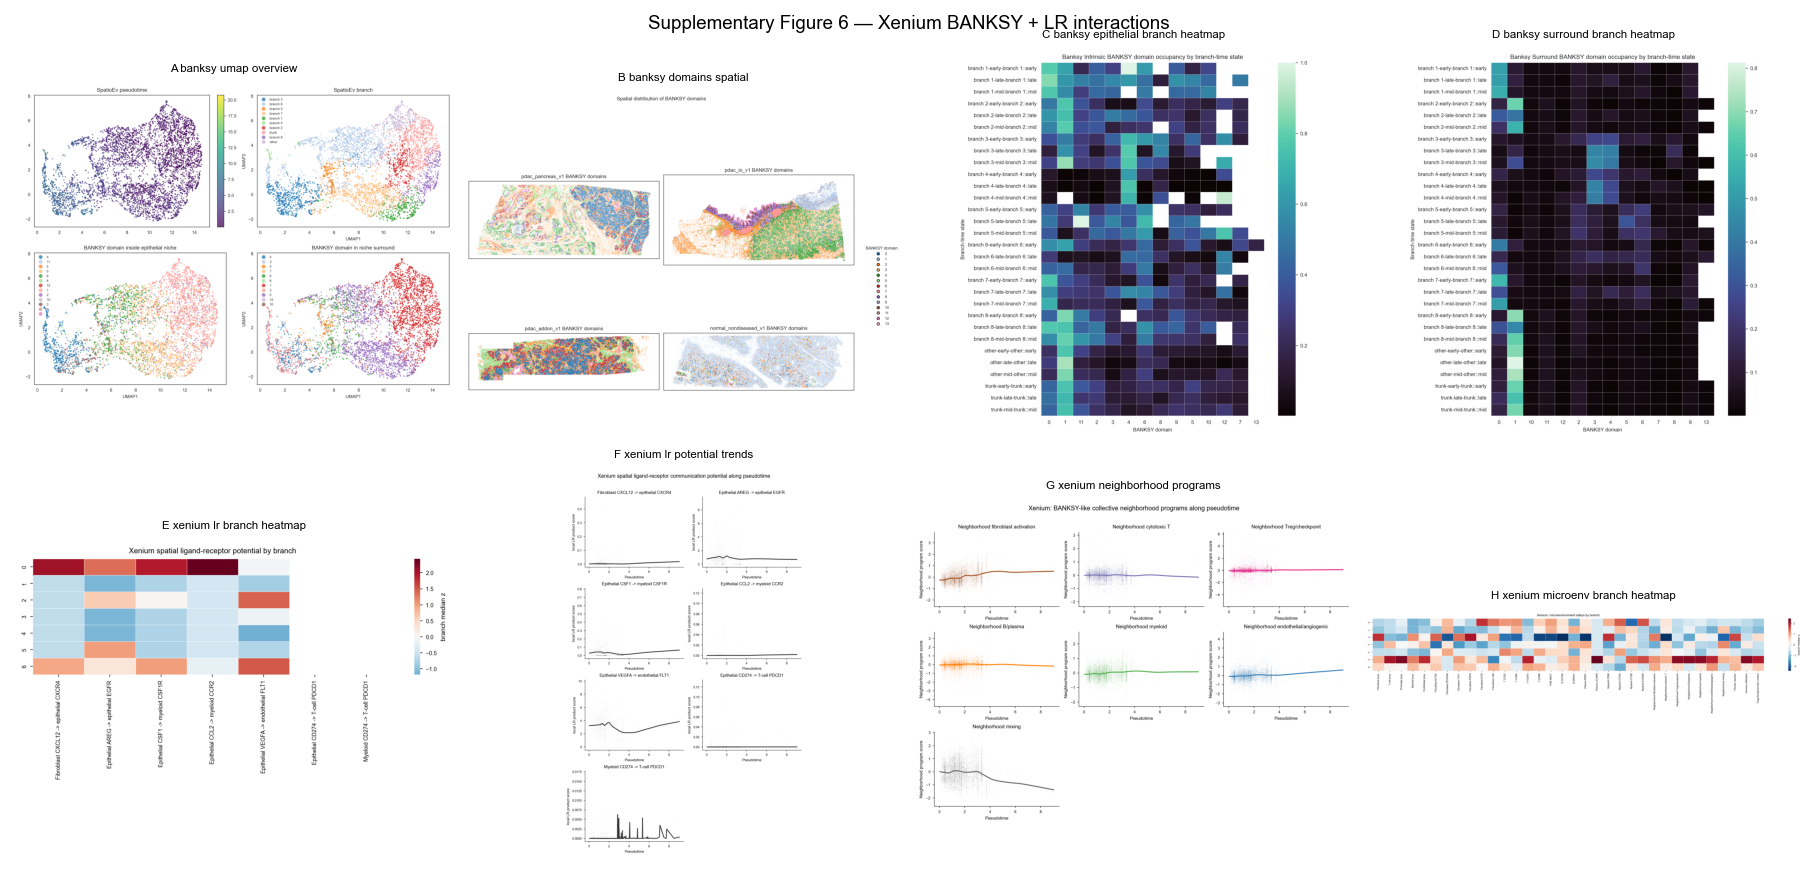

In [7]:
# Copy BANKSY panels
banksy_panels = {
    'supfig6A_banksy_umap_overview.png':              'xenium_banksy_umap_overview.png',
    'supfig6B_banksy_domains_spatial.png':            'xenium_banksy_domains_spatial_by_sample.png',
    'supfig6C_banksy_epithelial_branch_heatmap.png':  'xenium_banksy_intrinsic_banksy_branch_time_heatmap.png',
    'supfig6D_banksy_surround_branch_heatmap.png':    'xenium_banksy_surround_banksy_branch_time_heatmap.png',
}
for dest, src in banksy_panels.items():
    copy_fig(BANKSY_FIG / src, dest)

# Copy Xenium LR panels
xenium_lr_panels = {
    'supfig6E_xenium_lr_branch_heatmap.png': 'xenium_lr_branch_heatmap.png',
    'supfig6F_xenium_lr_potential_trends.png': 'xenium_lr_potential_trends.png',
    'supfig6G_xenium_neighborhood_programs.png': 'xenium_neighborhood_program_trends_sample_centered.png',
    'supfig6H_xenium_microenv_branch_heatmap.png': 'xenium_microenvironment_branch_heatmap.png',
}
for dest, src in xenium_lr_panels.items():
    copy_fig(TRAJ_FIG / src, dest)

# Composite
all_s6 = list(banksy_panels.keys()) + list(xenium_lr_panels.keys())
panel_files_s6 = [OUT / p for p in all_s6 if (OUT / p).exists()]
n = len(panel_files_s6)
ncols = 4; nrows = (n + 3) // 4
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.0, nrows * 2.8), constrained_layout=True)
axes = np.array(axes).reshape(-1)
for ax, pf in zip(axes, panel_files_s6):
    ax.imshow(mpimg.imread(pf))
    ax.axis('off')
    ax.set_title(pf.stem.replace('supfig6', '').replace('_', ' ').strip(), fontsize=5.5)
for ax in axes[n:]:
    ax.set_visible(False)
fig.suptitle('Supplementary Figure 6 — Xenium BANKSY + LR interactions', fontsize=9, y=1.01)
save_fig(fig, 'supfig6_xenium_banksy_lr_composite')
plt.show()

---
## Supplementary Sections 7–11 — SpatioEv Package Demo Figures

These sections copy pre-generated figures from the package demonstration notebooks.

Saved: supsec7_svm_phenotyping


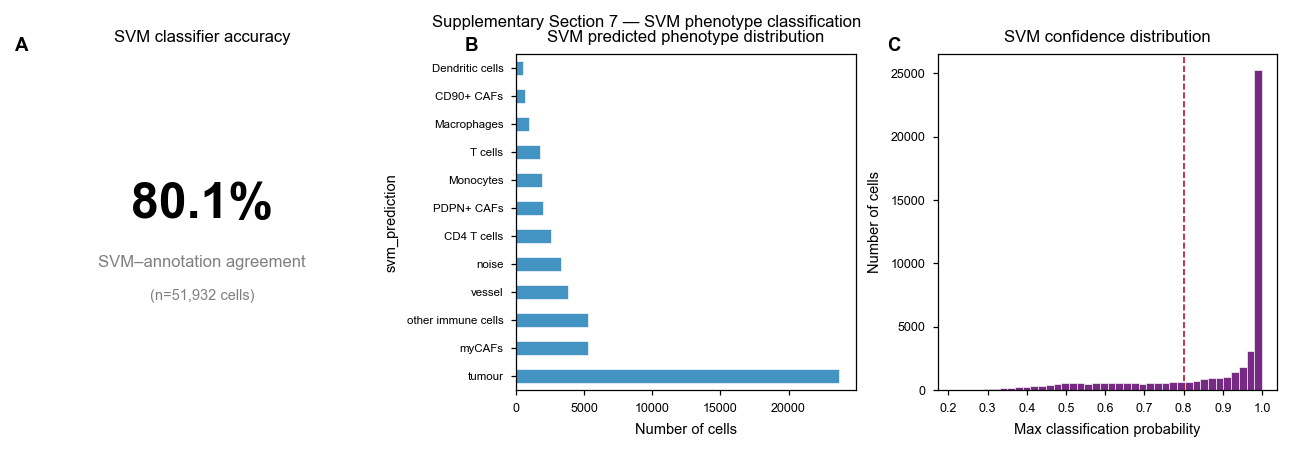

In [8]:
# ── Sup Section 7: Phenotyping (SVM) ─────────────────────────────────────────
df_svm = pd.read_csv(BASE / 'results/svm_phenotyping_results.csv')
df_prob = pd.read_csv(BASE / 'results/svm_phenotyping_probabilities.csv')

fig, axes = plt.subplots(1, 3, figsize=(8.5, 2.8), constrained_layout=True)

# Panel A: Annotation agreement (original vs SVM)
ax = axes[0]
if 'annotated_clusters_update3' in df_svm.columns and 'svm_prediction' in df_svm.columns:
    agree = (df_svm['annotated_clusters_update3'] == df_svm['svm_prediction']).mean() * 100
    ax.text(0.5, 0.55, f'{agree:.1f}%', ha='center', va='center',
            fontsize=24, fontweight='bold', transform=ax.transAxes)
    ax.text(0.5, 0.38, 'SVM–annotation agreement', ha='center', va='center',
            fontsize=8, transform=ax.transAxes, color='gray')
    ax.text(0.5, 0.28, f'(n={len(df_svm):,} cells)', ha='center', va='center',
            fontsize=7, transform=ax.transAxes, color='gray')
ax.axis('off')
ax.set_title('SVM classifier accuracy')
ax.text(-0.05, 1.05, 'A', transform=ax.transAxes, fontsize=9, fontweight='bold', va='top')

# Panel B: Prediction class distribution
ax = axes[1]
if 'svm_prediction' in df_svm.columns:
    pred_counts = df_svm['svm_prediction'].value_counts().head(12)
    pred_counts.plot(kind='barh', ax=ax, color='#4393C3', edgecolor='white', linewidth=0.3)
    ax.set_xlabel('Number of cells')
    ax.set_title('SVM predicted phenotype distribution')
    ax.tick_params(axis='y', labelsize=5.5)
ax.text(-0.15, 1.05, 'B', transform=ax.transAxes, fontsize=9, fontweight='bold', va='top')

# Panel C: Max probability distribution
ax = axes[2]
if df_prob.shape[1] > 1:
    # FIX: select only numeric svm_prob_ columns; 'Unnamed: 0' / index cols are str dtype
    prob_cols = [c for c in df_prob.columns if c.startswith('svm_prob_')]
    if not prob_cols:  # fallback: any numeric column
        prob_cols = df_prob.select_dtypes(include='number').columns.tolist()
    max_probs = df_prob[prob_cols].max(axis=1)
    ax.hist(max_probs, bins=40, color='#762A83', edgecolor='white', linewidth=0.3)
    ax.axvline(0.8, color='#B2182B', linestyle='--', linewidth=0.8)
    ax.set_xlabel('Max classification probability')
    ax.set_ylabel('Number of cells')
    ax.set_title('SVM confidence distribution')
ax.text(-0.15, 1.05, 'C', transform=ax.transAxes, fontsize=9, fontweight='bold', va='top')

fig.suptitle('Supplementary Section 7 — SVM phenotype classification', fontsize=8, y=1.02)
save_fig(fig, 'supsec7_svm_phenotyping')
plt.show()

In [9]:
# ── Sup Section 8: Spatial statistics (Ripley's K / Moran's I) ────────────────
# Copy from global_organization results if available
STATS_DIR = BASE / 'paper/notebooks/results/global_organization_pdac_igg4aip'

# Cross-Ripley K summary
cross_ripley_pkl = STATS_DIR / 'tier_a_cross_ripley.pkl'
if cross_ripley_pkl.exists():
    df_cr = pd.read_pickle(cross_ripley_pkl)
    print('Cross-Ripley cols:', list(df_cr.columns)[:10])

# Cross-Moran summary
cross_moran = STATS_DIR / 'cross_moran_shortlist_permutations.csv'
if cross_moran.exists():
    df_moran = pd.read_csv(cross_moran)
    print('Cross-Moran cols:', list(df_moran.columns))
    print(df_moran.head(3).to_string())

Cross-Ripley cols: ['imageid', 'source', 'target', 'radius', 'K_observed', 'K_expected', 'L', 'L_minus_r', 'mean_target_neighbors_per_source', 'expected_target_neighbors_per_source']
Cross-Moran cols: ['sample_id', 'disease', 'source_phenotype', 'target_phenotype', 'source_feature', 'target_feature', 'observed', 'p_value', 'null_mean', 'null_std', 'z_score', 'n_sim']
  sample_id  disease              source_phenotype target_phenotype  source_feature target_feature  observed  p_value  null_mean  null_std    z_score  n_sim
0   29624_1  IgG4AIP  pancreatic ductal epithelium      Fibroblasts       CK19_expr       FAP_expr -0.063021    0.005   0.000303  0.007371  -8.591197    199
1   29624_1  IgG4AIP  pancreatic ductal epithelium      Fibroblasts       Ki67_expr      PDPN_expr  0.128230    0.005  -0.000300  0.006659  19.300683    199
2   29624_1  IgG4AIP  pancreatic ductal epithelium          T cells  NaKATPase_expr      GZMB_expr  0.102303    0.005   0.000516  0.011930   8.531928    199


In [10]:
# Cross-Moran heatmap if data available
if cross_moran.exists():
    df_moran = pd.read_csv(cross_moran)
    if 'feature_a' in df_moran.columns and 'feature_b' in df_moran.columns:
        pivot_col = [c for c in df_moran.columns if 'moran' in c.lower() or 'rho' in c.lower() or 'correlation' in c.lower()]
        if pivot_col:
            pivot = df_moran.pivot_table(index='feature_a', columns='feature_b',
                                         values=pivot_col[0], aggfunc='mean')
            fig, ax = plt.subplots(figsize=(min(8, pivot.shape[1] * 0.6 + 1),
                                             min(6, pivot.shape[0] * 0.5 + 1)),
                                   constrained_layout=True)
            sns.heatmap(pivot, cmap='RdBu_r', center=0, ax=ax,
                        annot=pivot.shape[0] <= 12,
                        fmt='.2f', annot_kws={'size': 5},
                        linewidths=0.3, linecolor='white',
                        cbar_kws={'shrink': 0.6, 'label': pivot_col[0]})
            ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=5)
            ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=5)
            ax.set_title('Cross-Moran\u2019s I — epithelial-target feature coupling')
            fig.suptitle('Supplementary Section 8 — Spatial statistics', fontsize=8, y=1.02)
            save_fig(fig, 'supsec8_cross_morans_i_heatmap')
            plt.show()
        else:
            print('No Moran column found in cross_moran CSV:', list(df_moran.columns))
    else:
        print('Unexpected cross-Moran CSV format:', list(df_moran.columns))

Unexpected cross-Moran CSV format: ['sample_id', 'disease', 'source_phenotype', 'target_phenotype', 'source_feature', 'target_feature', 'observed', 'p_value', 'null_mean', 'null_std', 'z_score', 'n_sim']


Copied: supsec9A_spatial_qc_col6_overlay.png
Copied: supsec9B_col6_cell_fraction.png
Copied: supsec9C_col6_cell_density.png
Copied: supsec9D_nearest_fiber_distance.png
Copied: supsec9E_fiber_density_near_cells.png
Copied: supsec9F_cross_ripleys_k_fiber.png
Copied: supsec9G_perivascular_col6_density.png
Copied: supsec9H_fiber_morans_i.png
Copied: supsec9I_delta_fiber_morans_heatmap.png
Copied: supsec9J_local_moran_col6_example.png
Copied: supsec9K_cross_morans_ecm_cell.png
Copied: supsec9L_local_cross_moran_example.png
Copied: supsec9M_chp_density_JRP112.png
Copied: supsec9N_chp_core_edge_JRP112.png
Copied: supsec9O_chp_kde_JRP112.png
Saved: supsec9_ecm_cell_composite


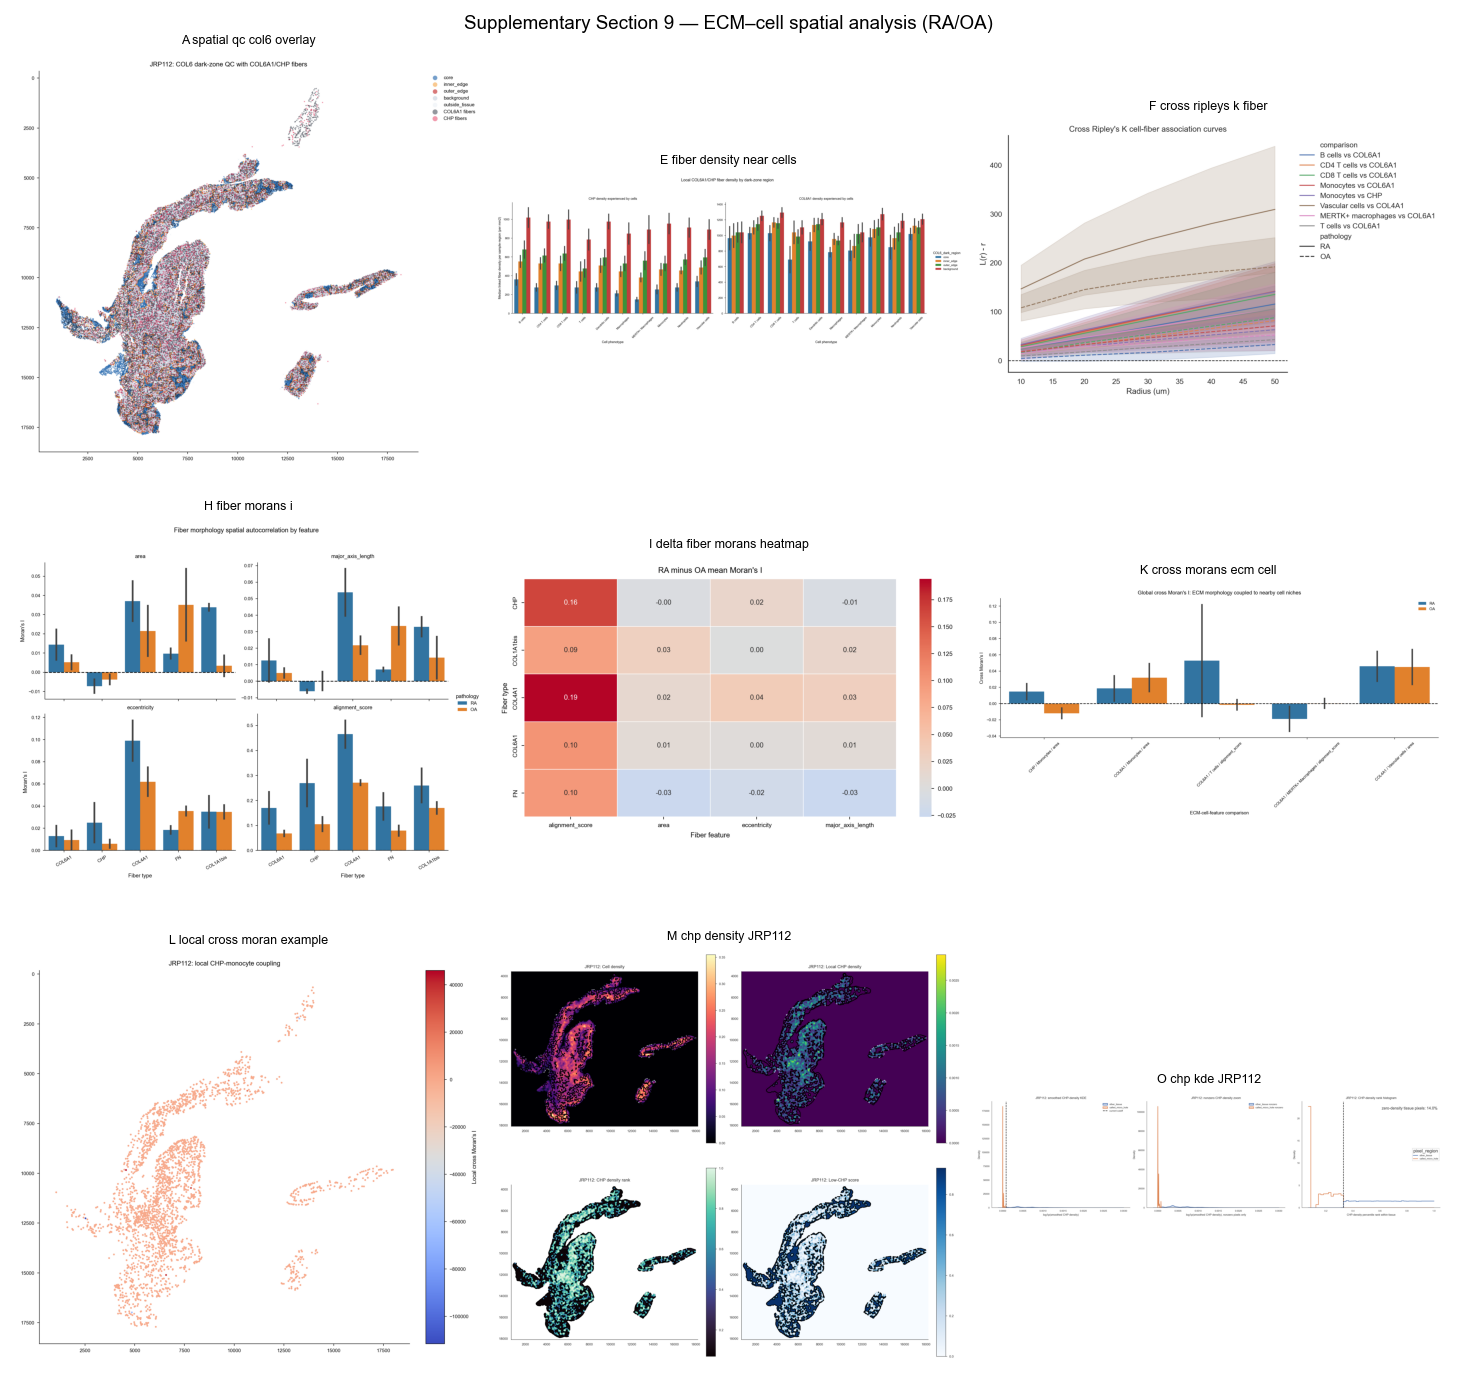

In [11]:
# ── Sup Section 9: ECM-cell spatial analysis (RA/OA dataset) ─────────────────
ecm_panels = {
    'supsec9A_spatial_qc_col6_overlay.png':        '00_spatial_qc_col6_dark_zone_ecm_overlay.png',
    'supsec9B_col6_cell_fraction.png':             '01_col6_dark_region_cell_fraction_by_phenotype.png',
    'supsec9C_col6_cell_density.png':              '02_col6_dark_region_cell_density_per_area.png',
    'supsec9D_nearest_fiber_distance.png':         '03_nearest_cell_to_fiber_distance_by_phenotype.png',
    'supsec9E_fiber_density_near_cells.png':       '04_fiber_density_near_cells_col6_chp.png',
    'supsec9F_cross_ripleys_k_fiber.png':          '05_cross_ripleys_k_cell_fiber_curves.png',
    'supsec9G_perivascular_col6_density.png':      '06_perivascular_col6_density_by_cell_type.png',
    'supsec9H_fiber_morans_i.png':                 '07_fiber_morans_i_by_type_pathology.png',
    'supsec9I_delta_fiber_morans_heatmap.png':     '07b_group_delta_fiber_morans_i_heatmap.png',
    'supsec9J_local_moran_col6_example.png':       '08_local_moran_col6_alignment_example.png',
    'supsec9K_cross_morans_ecm_cell.png':          '09_cross_morans_i_ecm_cell_coupling.png',
    'supsec9L_local_cross_moran_example.png':      '10_local_cross_moran_chp_monocyte_example.png',
}
for dest, src in ecm_panels.items():
    copy_fig(ECM_FIG / src, dest)

# CHP density micro-holes (representative samples)
chp_panels = {
    'supsec9M_chp_density_JRP112.png':   '01_JRP112_chp_micro_hole_density_rank_score.png',
    'supsec9N_chp_core_edge_JRP112.png': '02_JRP112_chp_micro_hole_core_edge_overlay.png',
    'supsec9O_chp_kde_JRP112.png':       '05_JRP112_smoothed_chp_density_kde.png',
}
for dest, src in chp_panels.items():
    copy_fig(CHP_FIG / src, dest)

# Composite ECM panel (3×4 grid of key panels)
key_ecm = ['supsec9A_spatial_qc_col6_overlay.png', 'supsec9E_fiber_density_near_cells.png',
           'supsec9F_cross_ripleys_k_fiber.png', 'supsec9H_fiber_morans_i.png',
           'supsec9I_delta_fiber_morans_heatmap.png', 'supsec9K_cross_morans_ecm_cell.png',
           'supsec9L_local_cross_moran_example.png', 'supsec9M_chp_density_JRP112.png',
           'supsec9O_chp_kde_JRP112.png']
panel_files_ecm = [OUT / p for p in key_ecm if (OUT / p).exists()]
n = len(panel_files_ecm)
ncols = 3; nrows = (n + 2) // 3
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.2, nrows * 3.0), constrained_layout=True)
axes = np.array(axes).reshape(-1)
for ax, pf in zip(axes, panel_files_ecm):
    ax.imshow(mpimg.imread(pf))
    ax.axis('off')
    ax.set_title(pf.stem.replace('supsec9', '').replace('_', ' ').strip(), fontsize=6)
for ax in axes[n:]:
    ax.set_visible(False)
fig.suptitle('Supplementary Section 9 — ECM–cell spatial analysis (RA/OA)', fontsize=9, y=1.01)
save_fig(fig, 'supsec9_ecm_cell_composite')
plt.show()

In [12]:
# ── Final: print all generated files ─────────────────────────────────────────
import os
all_files = sorted([f for f in os.listdir(OUT) if f.endswith('.pdf') or f.endswith('.png')])
print(f'Total files in {OUT.name}/: {len(all_files)}')
for f in all_files:
    size_kb = (OUT / f).stat().st_size // 1024
    print(f'  {f}  ({size_kb} KB)')

Total files in supplementary/: 50
  supfig1_33694_1_pseudotime.pdf  (1177 KB)
  supfig1_33694_1_pseudotime.png  (1689 KB)
  supfig1_35559_1_pseudotime.pdf  (1256 KB)
  supfig1_35559_1_pseudotime.png  (1685 KB)
  supfig1_40331_1_pseudotime.pdf  (592 KB)
  supfig1_40331_1_pseudotime.png  (1035 KB)
  supfig2_feature_selection_pca.pdf  (35 KB)
  supfig2_feature_selection_pca.png  (146 KB)
  supfig3_epi_vs_contextual_pseudotime.pdf  (1324 KB)
  supfig3_epi_vs_contextual_pseudotime.png  (1644 KB)
  supfig3_epi_vs_contextual_pseudotime_pregenerated.pdf  (507 KB)
  supfig4A_microenv_trends.png  (646 KB)
  supfig4B_microenv_branch_heatmap.png  (110 KB)
  supfig4C_colocalisation_trends.png  (434 KB)
  supfig4D_branch_state_heatmap.png  (143 KB)
  supfig4E_transition_events.png  (175 KB)
  supfig4F_subway_map.png  (272 KB)
  supfig4_microenv_dynamics_composite.pdf  (737 KB)
  supfig4_microenv_dynamics_composite.png  (854 KB)
  supfig5_pseudotime_concordance.pdf  (69 KB)
  supfig5_pseudotime_conco